<a href="https://colab.research.google.com/github/iceik973-dotcom/ML1/blob/main/%D0%9B%D0%A0_5__%D0%93%D1%80%D0%B8%D0%B3%D0%BE%D1%80%D0%B8%D1%88%D0%B5%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Weather Time Series Data - Delhi, India**

https://www.kaggle.com/datasets/yug201/daily-climate-time-series-data-delhi-india?select=kaggel_weather_2013_to_2024.csv

**Тема:** Прогнозування часових рядів на основі кліматичних даних

**Мета роботи:**
Навчитися виконувати аналіз часових рядів, проводити дослідницький аналіз даних (EDA), визначати автокореляційні залежності, будувати моделі прогнозування та оцінювати їхню точність.

**Вихідні дані**

Для виконання роботи використовується датасет Daily Climate Time Series Data (Delhi, India) з платформи Kaggle, який містить щоденні кліматичні показники (температура, вологість, опади тощо) за кілька років.


1. Завантажити датасет з Kaggle.

2. Імпортувати дані у середовище Python (Jupyter Notebook або Google Colab).

3. Ознайомитися зі структурою датасету (head(), info(), describe()).

4. Попередня обробка даних

-Перетворити колонку з датою у формат datetime.

-Відсортувати дані за датою.

-Встановити дату як індекс часового ряду.

-Перевірити наявність пропущених значень та за необхідності обробити їх.

5. Дослідницький аналіз даних (EDA)

-Побудувати графік зміни температури у часі.

-Побудувати ковзне середнє значення температури.

-Побудувати гістограму розподілу температури.

-Побудувати boxplot для виявлення можливих викидів.

-Аналіз автокореляції

Побудувати графік автокореляційної функції (ACF).

Побудувати графік часткової автокореляції (PACF).

-Проаналізувати залежність значень часового ряду від попередніх періодів.

6.Підготовка даних для моделювання

-Розділити дані на тренувальну та тестову вибірки (наприклад, 80% / 20%).

7. Побудувати щонайменше три моделі прогнозування:

-ARIMA (класична статистична модель);

-Prophet (модель прогнозування часових рядів від Meta);

-LSTM (нейронна мережа для послідовних даних).

8. Оцінка моделей
Для кожної моделі обчислити метрики:

-MAE (Mean Absolute Error)

-RMSE (Root Mean Squared Error)

-MAPE (Mean Absolute Percentage Error)

8.Візуалізація результатів

-Побудувати графіки прогнозованих та фактичних значень.

-Побудувати порівняльний графік прогнозів усіх моделей.

-Порівняння моделей

-Створити таблицю з метриками точності.

9.Визначити модель, яка показала найкращий результат.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

warnings.filterwarnings("ignore")
plt.style.use("default")


In [2]:
import kagglehub

path = kagglehub.dataset_download("yug201/daily-climate-time-series-data-delhi-india")

print("Path to dataset files:", path)

100%|██████████| 194k/194k [00:00<00:00, 66.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yug201/daily-climate-time-series-data-delhi-india/versions/1


In [3]:
df = pd.read_csv(os.path.join(path, "kaggel_weather_2013_to_2024.csv"))
display(df)

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
0,0,4/14/2013,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
1,1,4/15/2013,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2,2,4/16/2013,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
3,3,4/17/2013,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
4,4,4/18/2013,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,3552,11/26/2024,25.8,13.6,18.6,25.8,13.6,18.6,65.9,0.0,...,24,48,1700.22,896.24,1225.74,1700.22,896.24,1225.74,12.2,242.171864
3553,3553,11/27/2024,26.2,12.5,18.4,26.2,12.5,18.4,61.0,0.0,...,24,48,1598.20,762.50,1122.40,1598.20,762.50,1122.40,13.7,236.769595
3554,3554,11/28/2024,25.8,11.5,17.9,25.8,11.5,17.9,63.1,0.0,...,24,48,1627.98,725.65,1129.49,1627.98,725.65,1129.49,14.3,243.117035
3555,3555,11/29/2024,25.0,10.6,18.0,25.0,10.6,18.0,60.0,0.0,...,24,48,1500.00,636.00,1080.00,1500.00,636.00,1080.00,14.4,237.638344


**ДАТА** : Дата спостереження.

**Температура** : tempmax, tempmin, temp.

**Відчутна температура** : feelslikemax, feelslikemin, feelslike.

**Вологість**: Середня відносна вологість.

**Опади** : precip, precipprob, precipcover.

**Вітер і тиск** : windspeed, sealevelpressure.

**Умови** : Опис погоди (Ясно, Дощ, Хмарно тощо).

**Похідні показники** : temp_range, heat_index.

Підготовка даних

In [4]:

df["DATE"] = pd.to_datetime(df["DATE"])

df = df.sort_values("DATE")

df = df.drop(columns=["Unnamed: 0"])

df = df.set_index("DATE")

df.head()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,precipcover,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
DATE,,,,,,,,,,,,,,,,,,,,,
2013-04-14,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,100,4.17,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
2013-04-15,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,0,0.00,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2013-04-16,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,0,0.00,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
2013-04-17,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,0,0.00,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
2013-04-18,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,0,0.00,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3557 entries, 2013-04-14 to 2024-11-30
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tempmax                3557 non-null   float64
 1   tempmin                3557 non-null   float64
 2   temp                   3557 non-null   float64
 3   feelslikemax           3557 non-null   float64
 4   feelslikemin           3557 non-null   float64
 5   feelslike              3557 non-null   float64
 6   humidity               3557 non-null   float64
 7   precip                 3557 non-null   float64
 8   precipprob             3557 non-null   int64  
 9   precipcover            3557 non-null   float64
 10  windspeed              3557 non-null   float64
 11  sealevelpressure       3557 non-null   float64
 12  conditions             3557 non-null   object 
 13  Year                   3557 non-null   int64  
 14  month                  3557 non-null  

In [6]:
df.isnull().sum()

,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
humidity,0
precip,0
precipprob,0
precipcover,0


Графік температури

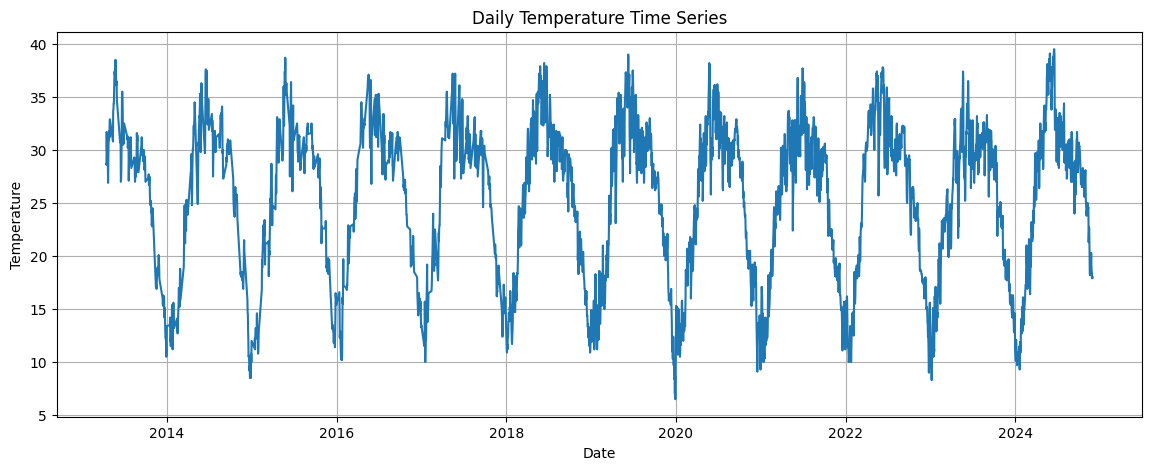

In [7]:
plt.figure(figsize=(14,5))
plt.plot(df["temp"])
plt.title("Daily Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid()
plt.show()

Ковзне середнє

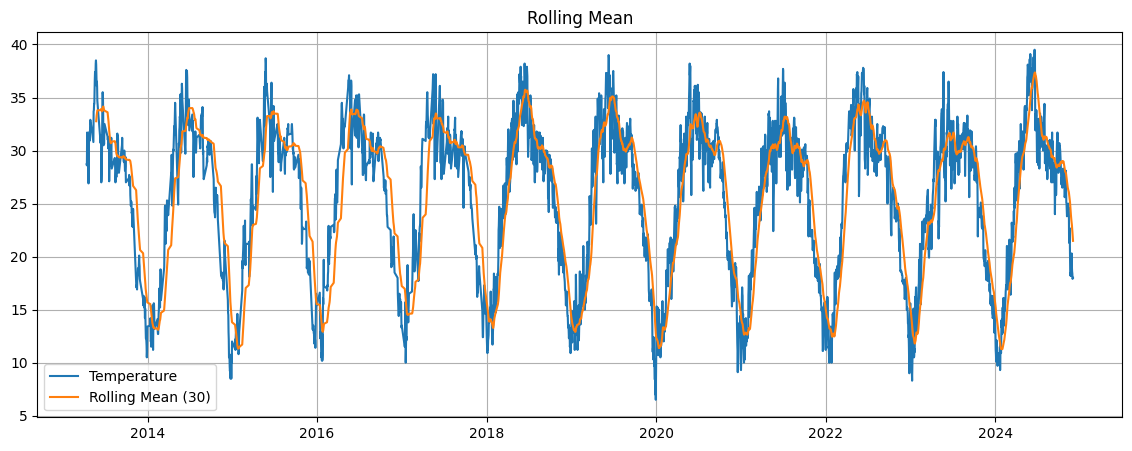

In [8]:
df["rolling_mean"] = df["temp"].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(df["temp"], label="Temperature")
plt.plot(df["rolling_mean"], label="Rolling Mean (30)")
plt.title("Rolling Mean")
plt.legend()
plt.grid()
plt.show()

Розподіл температури

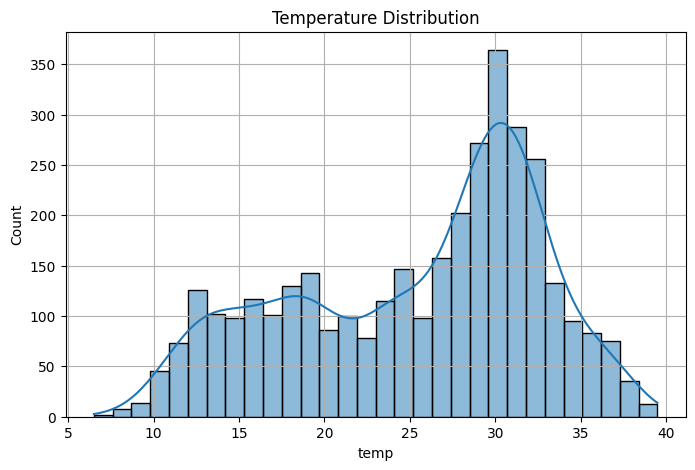

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["temp"], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.grid()
plt.show()

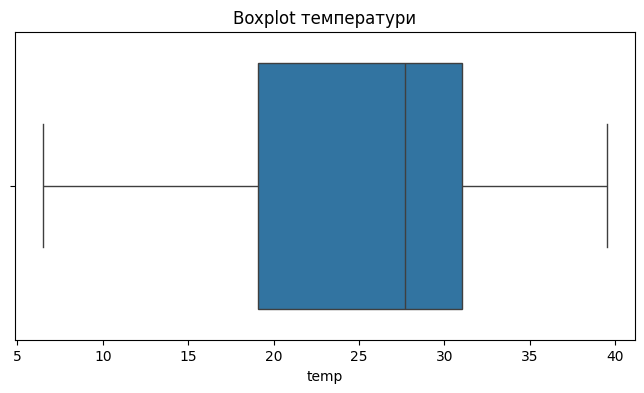

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["temp"])
plt.title("Boxplot температури")
plt.show()

Аналіз автокореляції
ACF

PACF

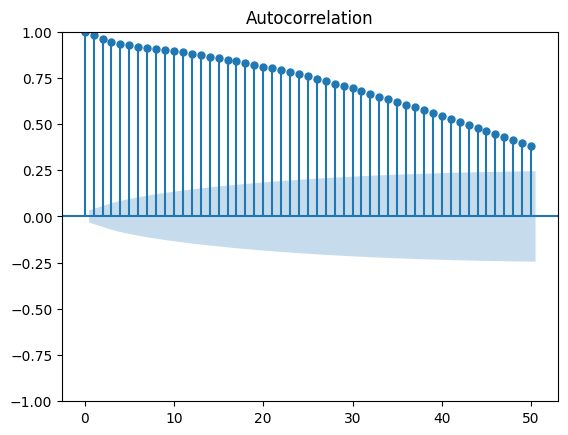

In [11]:
plot_acf(df["temp"], lags=50)
plt.show()

Автокореляційна функція (ACF) використовується для аналізу залежності значень часового ряду від його попередніх значень. Вона відображає ступінь кореляції між значенням показника у певний момент часу та значеннями цього самого показника у попередні моменти часу, які називаються лагами. Побудова графіка автокореляційної функції дозволяє виявити, чи існує статистично значуща залежність між поточним значенням ряду та його попередніми спостереженнями. На такому графіку по горизонтальній осі відкладаються лаги, тобто кількість часових кроків назад, а по вертикальній — значення коефіцієнта автокореляції. Аналіз графіка ACF дає можливість виявити наявність тренду, сезонності або інших закономірностей у часовому ряді, а також використовується для визначення параметрів статистичних моделей прогнозування, зокрема моделі ARIMA.

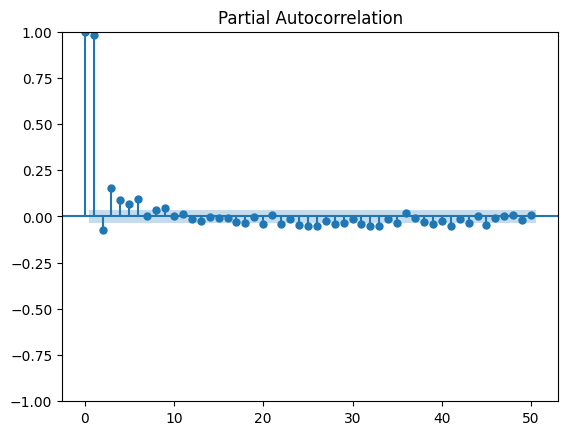

In [12]:
plot_pacf(df["temp"], lags=50)
plt.show()

Часткова автокореляційна функція (PACF) застосовується для більш точного визначення залежності між значеннями часового ряду. На відміну від звичайної автокореляційної функції, PACF вимірює кореляцію між значенням ряду у певний момент часу та значенням у попередній момент часу з конкретним лагом, усуваючи вплив усіх проміжних лагів. Таким чином, часткова автокореляція показує «чисту» залежність між двома спостереженнями часового ряду. Побудова графіка PACF дозволяє визначити, які саме лаги мають статистично значущий вплив на значення ряду. Це є важливим етапом під час побудови моделей прогнозування часових рядів, оскільки аналіз графіка часткової автокореляції використовується для визначення порядку авторегресійної складової моделі, зокрема параметра
𝑝 у моделі ARIMA.

In [13]:
target = df["temp"].copy()

split_index = int(len(target) * 0.8)

train = target.iloc[:split_index]
test = target.iloc[split_index:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2845
Test size: 712


ARIMA

https://developer.ibm.com/tutorials/awb-arima-models-in-python/

In [14]:
train_arima = train.reset_index(drop=True)

arima_model = ARIMA(train_arima, order=(5, 1, 2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

print(arima_forecast.head())

DATE
2022-12-20    14.895737
2022-12-21    15.071189
2022-12-22    15.161451
2022-12-23    15.179429
2022-12-24    15.200756
Name: predicted_mean, dtype: float64


In [15]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2845
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -4969.050
Date:                Fri, 09 Oct 2026   AIC                           9954.101
Time:                        11:18:23   BIC                          10001.724
Sample:                             0   HQIC                          9971.277
                               - 2845                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1810      0.227      0.799      0.424      -0.263       0.625
ar.L2          0.1094      0.205      0.533      0.594      -0.293       0.511
ar.L3         -0.1108      0.049     -2.242      0.0

сигма 2 : це представляє дисперсію залишкових значень, чим менше, тим краще

логарифмічна правдоподібність : це оцінка максимальної правдоподібності для моделі ARIMA, чим вище, тим краще

aic : міра ступеню відповідності та економності моделі, чим нижче, тим краще

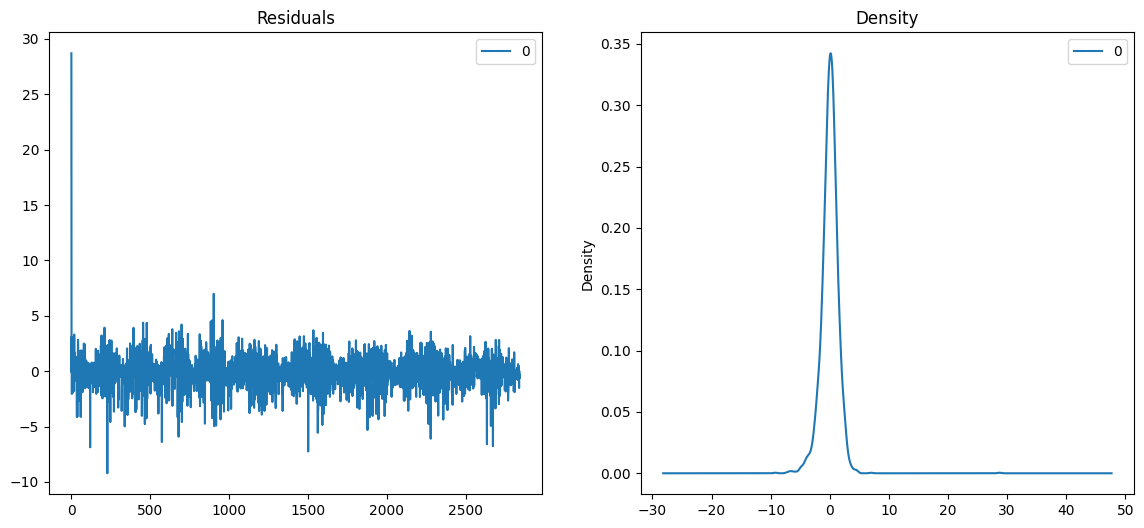

In [16]:
import pandas as pd

residuals = pd.DataFrame(arima_fit.resid)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

In [17]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = mape(test, arima_forecast)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA MAE: 10.92780938078051
ARIMA RMSE: 12.500912027305812
ARIMA MAPE: 39.591987075351994


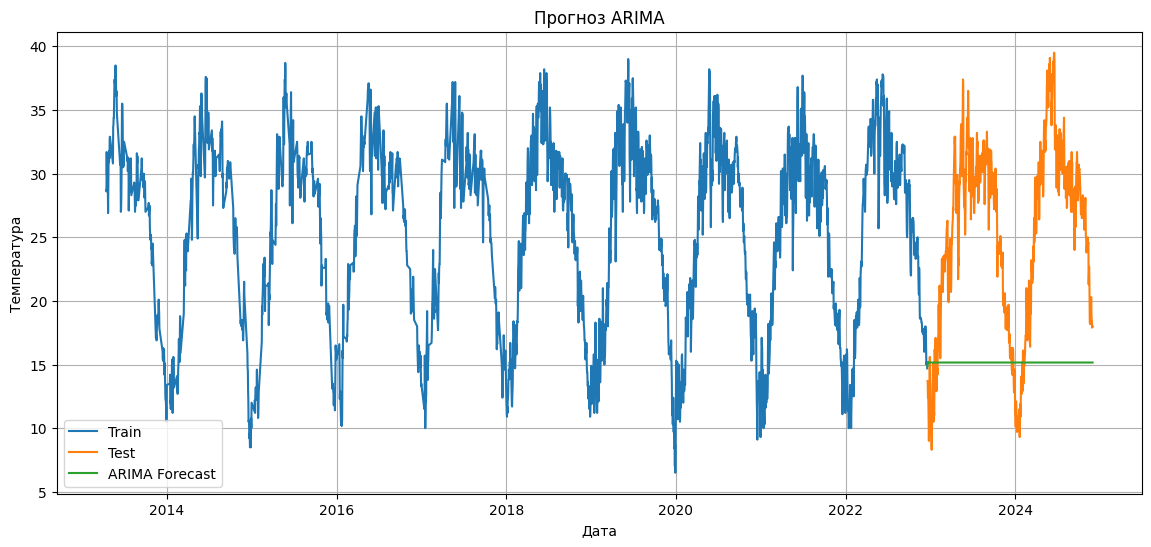

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")
plt.title("Прогноз ARIMA")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

PROPHET

https://facebook.github.io/prophet/docs/quick_start.html

In [19]:
prophet_df = df.reset_index()[["DATE", "temp"]].copy()
prophet_df.columns = ["ds", "y"]

prophet_train = prophet_df.iloc[:split_index].copy()
prophet_test = prophet_df.iloc[split_index:].copy()

In [20]:
from prophet import Prophet

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(prophet_train)

Прогноз

In [21]:
future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq="D")
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast = prophet_forecast_full[["ds", "yhat"]].tail(len(prophet_test)).copy()
prophet_forecast = prophet_forecast.set_index("ds")

prophet_test_indexed = prophet_test.set_index("ds")

In [22]:
prophet_mae = mean_absolute_error(prophet_test_indexed["y"], prophet_forecast["yhat"])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test_indexed["y"], prophet_forecast["yhat"]))
prophet_mape = mape(prophet_test_indexed["y"], prophet_forecast["yhat"])

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)
print("Prophet MAPE:", prophet_mape)

Prophet MAE: 2.004679994301011
Prophet RMSE: 2.5901965298397274
Prophet MAPE: 9.027934868552647


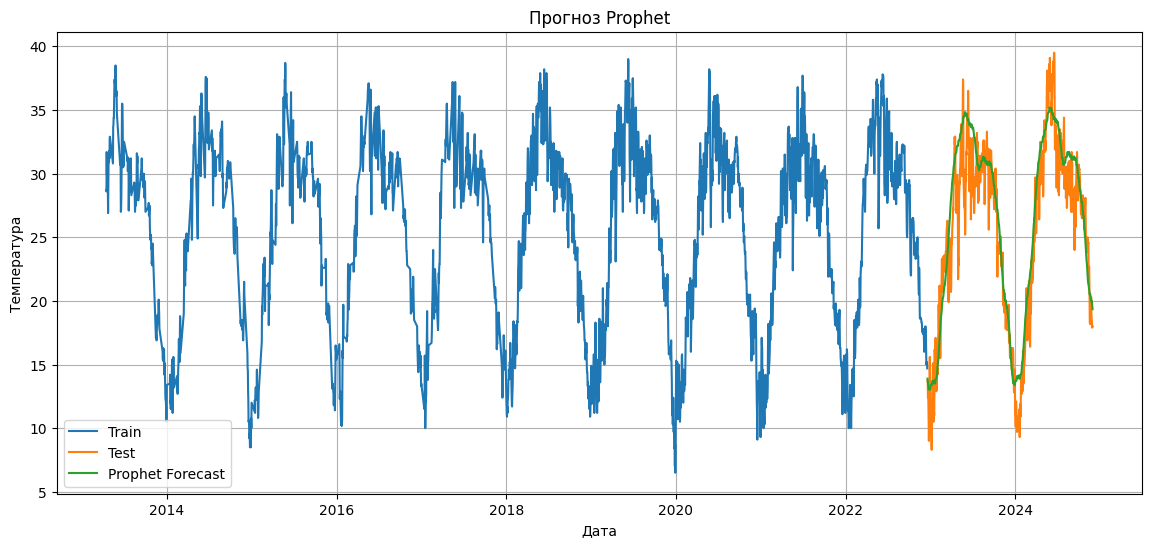

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Test")
plt.plot(prophet_forecast.index, prophet_forecast["yhat"], label="Prophet Forecast")
plt.title("Прогноз Prophet")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

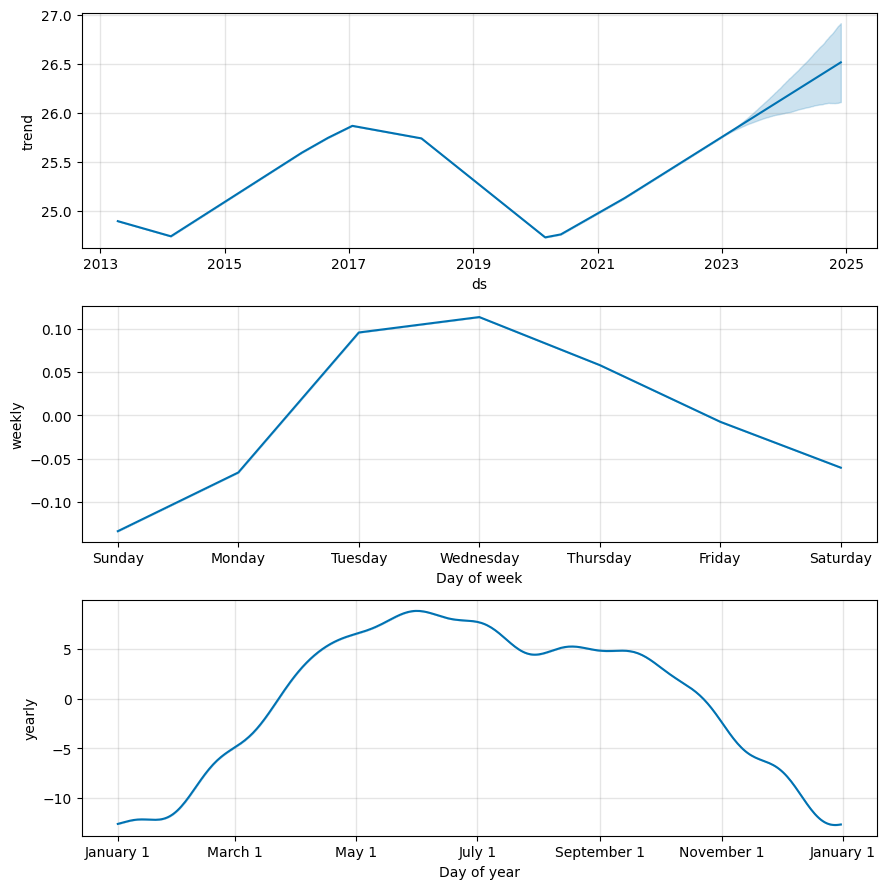

In [24]:
prophet_model.plot_components(prophet_forecast_full)
plt.show()

ПІДГОТОВКА ДАНИХ ДЛЯ LSTM

In [25]:
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df[["temp"]])

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_values)):
    X.append(scaled_values[i-sequence_length:i, 0])
    y.append(scaled_values[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3527, 30, 1)
y shape: (3527,)


In [26]:
split_lstm = int(len(X) * 0.8)

X_train = X[:split_lstm]
X_test = X[split_lstm:]

y_train = y[:split_lstm]
y_test = y[split_lstm:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2821, 30, 1)
X_test: (706, 30, 1)


In [27]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

In [28]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0283 - val_loss: 0.0057
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0062 - val_loss: 0.0047
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0052 - val_loss: 0.0043
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0052 - val_loss: 0.0041
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0047 - val_loss: 0.0051
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0046 - val_loss: 0.0042
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0043 - val_loss: 0.0037
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0041 - val_loss: 0.0034
Epoch 9/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0041 - val_loss: 0.0035
Epoch 10/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 11/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0035 - val_loss: 0.0030
Epoch 12/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0031 - val_

In [29]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [30]:
lstm_pred_scaled = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [31]:
lstm_dates = df.index[sequence_length:][split_lstm:]

In [32]:
lstm_mae = mean_absolute_error(y_test_real, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_pred))
lstm_mape = mape(y_test_real.flatten(), lstm_pred.flatten())

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

LSTM MAE: 1.171690555875092
LSTM RMSE: 1.549556554242378
LSTM MAPE: 5.235834017733214


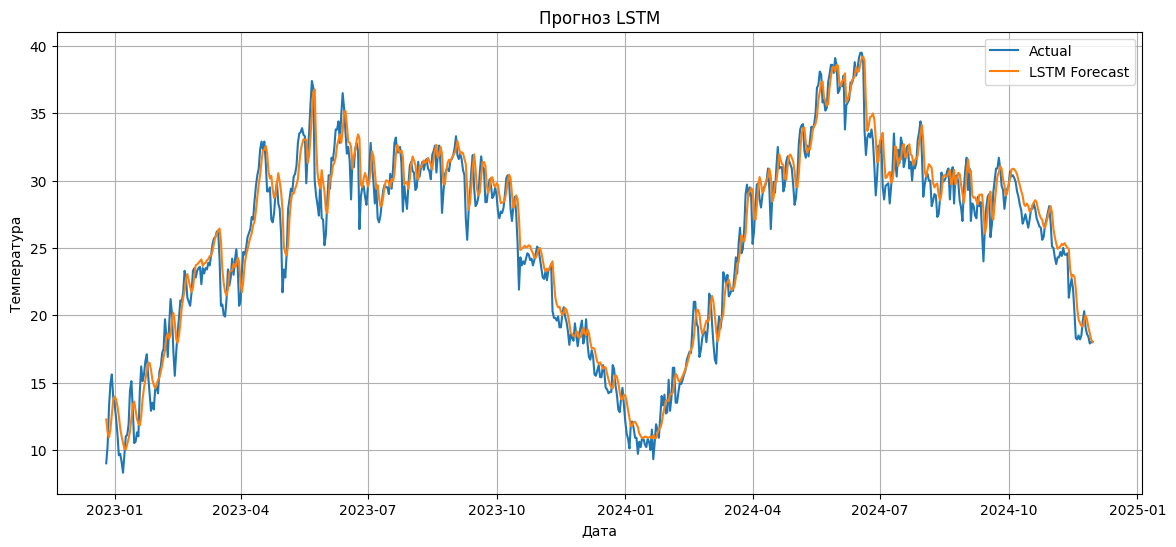

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(lstm_dates, y_test_real, label="Actual")
plt.plot(lstm_dates, lstm_pred, label="LSTM Forecast")
plt.title("Прогноз LSTM")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid(True)
plt.show()

Порівняння моделей

In [34]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "LSTM"],
    "MAE": [arima_mae, prophet_mae, lstm_mae],
    "RMSE": [arima_rmse, prophet_rmse, lstm_rmse],
    "MAPE": [arima_mape, prophet_mape, lstm_mape]
})

print(results.sort_values("RMSE"))

     Model        MAE       RMSE       MAPE
2     LSTM   1.171691   1.549557   5.235834
1  Prophet   2.004680   2.590197   9.027935
0    ARIMA  10.927809  12.500912  39.591987


У ході виконання роботи було проведено аналіз часового ряду температури на основі кліматичного датасету. На етапі попереднього аналізу було побудовано графіки динаміки температури, ковзного середнього, розподілу значень, а також графіки автокореляції та часткової автокореляції. Для прогнозування використано три моделі: ARIMA, Prophet та LSTM. Якість прогнозування оцінювалася за метриками MAE, RMSE та MAPE. На основі отриманих результатів було визначено модель, яка забезпечує найточніший прогноз для досліджуваного часового ряду.